In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [2]:
def linearKernel(x1, x2):
    x1 = x1.reshape(-1)
    x2 = x2.reshape(-1)
    sim = x1.T@x2
    return sim

In [3]:
def gaussianKernel(x1, x2, sigma):
    x1 = x1.reshape(-1)
    x2 = x2.reshape(-1)

    sim = 0
    sim = np.exp(-np.sum((x1-x2)**2)/2/sigma**2)
    return sim

In [4]:
def svmTrain(X, Y, C, kernelFunction, tol=1e-3, max_passes=5):
    m, n = X.shape

    # Map 0 to -1
    Y[Y == 0] = -1

    alphas = np.zeros(m)
    b = 0
    E = np.zeros(m)
    passes = 0
    eta = 0
    L = 0
    H = 0

    K = np.zeros((m, m))

    if kernelFunction.__name__ == 'linearKernel':
        K = np.dot(X, X.T)
    elif 'gaussianKernel' in kernelFunction.__name__:
        X2 = np.sum(X ** 2, axis=1)
        K = X2[:, np.newaxis] + X2[np.newaxis, :] - 2 * np.dot(X, X.T)
        sigma = kernelFunction.args[2]
        K = np.exp(-K / (2 * sigma ** 2))
    else:
        for i in range(m):
            for j in range(i, m):
                K[i, j] = kernelFunction(X[i, :], X[j, :])
                K[j, i] = K[i, j]

    print('\nTraining ...')
    dots = 12
    while passes < max_passes:
        num_changed_alphas = 0
        for i in range(m):
            E[i] = b + np.sum(alphas * Y * K[:, i]) - Y[i]
            if ((Y[i] * E[i] < -tol and alphas[i] < C) or
                (Y[i] * E[i] > tol and alphas[i] > 0)):

                j = np.random.randint(m)
                while j == i:
                    j = np.random.randint(m)

                E[j] = b + np.sum(alphas * Y * K[:, j]) - Y[j]

                alpha_i_old = alphas[i]
                alpha_j_old = alphas[j]

                if Y[i] == Y[j]:
                    L = max(0, alphas[j] + alphas[i] - C)
                    H = min(C, alphas[j] + alphas[i])
                else:
                    L = max(0, alphas[j] - alphas[i])
                    H = min(C, C + alphas[j] - alphas[i])

                eta = 2 * K[i, j] - K[i, i] - K[j, j]
                if eta >= 0:
                    continue

                alphas[j] = alphas[j] - (Y[j] * (E[i] - E[j])) / eta
                alphas[j] = np.clip(alphas[j], L, H)

                if np.abs(alphas[j] - alpha_j_old) < tol:
                    alphas[j] = alpha_j_old
                    continue

                alphas[i] = alphas[i] + Y[i] * Y[j] * (alpha_j_old - alphas[j])

                b1 = b - E[i] - Y[i] * (alphas[i] - alpha_i_old) * K[i, j] - \
                    Y[j] * (alphas[j] - alpha_j_old) * K[i, j]
                b2 = b - E[j] - Y[i] * (alphas[i] - alpha_i_old) * K[i, j] - \
                    Y[j] * (alphas[j] - alpha_j_old) * K[j, j]

                if 0 < alphas[i] and alphas[i] < C:
                    b = b1
                elif 0 < alphas[j] and alphas[j] < C:
                    b = b2
                else:
                    b = (b1 + b2) / 2

                num_changed_alphas += 1

        if num_changed_alphas == 0:
            passes += 1
        else:
            passes = 0

        print('.', end='')
        dots += 1
        if dots > 78:
            dots = 0
            print()
            
    print(' Done! \n\n')

    idx = alphas > 0
    model = {
        'X': X[idx, :],
        'y': Y[idx],
        'kernelFunction': kernelFunction,
        'b': b,
        'alphas': alphas[idx],
        'w': np.dot((alphas * Y), X)
    }

    return model

In [5]:
def svmPredict(model, X):
    '''
    SVMPREDICT returns a vector of predictions using a trained SVM model
    (svmTrain). 
       pred = SVMPREDICT(model, X) returns a vector of predictions using a 
       trained SVM model (svmTrain). X is a mxn matrix where there each 
       example is a row. model is a svm model returned from svmTrain.
       predictions pred is a m x 1 column of predictions of {0, 1} values.
        
     Check if we are getting a column vector, if so, then assume that we only
     need to do prediction for a single example
    '''
    if (X.shape[1] == 1):
        # Examples should be in rows
        X = X.T
    
    # Dataset 
    m = X.shape[0]
    p = np.zeros((m, 1))
    pred = np.zeros((m, 1))
    
    if model["kernelFunction"] == 'linearKernel':
        # We can use the weights and bias directly if working with the 
        # linear kernel
        p = X @ model['w'] + model['b']
    elif  model["kernelFunction"] =='gaussianKernel':
        # Vectorized RBF Kernel
        # This is equivalent to computing the kernel on every pair of examples
        X1 = np.sum(X**2, axis=1)
        X2 = np.sum(model['X']**2, axis=1)
        s = X.shape[0]
        A = (X2.reshape((s,1)) + (-2*(X@(model['X']).T)[:,np.newaxis])).reshape((s,s))
        K = (X1.reshape((s,1)) + A[:,np.newaxis]).reshape((s,s))
        K = model['kernelFunction'](1, 0)**K
        K = model['y'].T@K[np.newaxis,:]
        K = model['alphas'].T@K[np.newaxis,:]
        p = np.sum(K, axis=1)
    else:
        # Other Non-linear kernel
        for i in np.arange(m):
            prediction = 0
            for j in np.arange(model['X'].shape[0]):
                prediction = prediction + model['alphas'][j] *(model['y'][j]).astype(np.float64)* model['kernelFunction']((X[i,:]).T,(model['X'][j,:]).T)
            p[i] = prediction + model['b']
    
    # Convert predictions into 0 / 1
    pred[np.where(p >= 0)] =  1
    pred[np.where(p <  0)] =  0
    
    return pred

In [6]:
def plotData(X,y):
    plt.figure
    plt.plot(X[np.where(y==1),0],X[np.where(y==1),1],'k+',linewidth = 2,markersize=7)
    plt.plot(X[np.where(y==0),0],X[np.where(y==0),1],'ko',markerfacecolor = 'y',markersize=7)
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend(['Admitted', 'Not admitted'])
    #plt.show()
   

In [7]:
def visualizeBoundaryLinear(X, y, model):
    '''
    VISUALIZEBOUNDARYLINEAR plots a linear decision boundary learned by theSVM
       VISUALIZEBOUNDARYLINEAR(X, y, model) plots a linear decision boundary 
       learned by the SVM and overlays the data on it
    '''
    w = model['w']
    b = model['b']
    xp = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)
    yp = -(w[0]*xp + b)/w[1]
    plotData(X, y)
    plt.plot(xp, yp, '-b')

In [8]:
def visualizeBoundary(X, y, model):
    # VISUALIZEBOUNDARY plots a non-linear decision boundary learned by the SVM
    # VISUALIZEBOUNDARYLINEAR(X, y, model) plots a non-linear decision
    # boundary learned by the SVM and overlays the data on it
    
    # Plot the training data on top of the boundary
    plotData(X, y)

    # Make classification predictions over a grid of values
    x1plot = np.linspace(min(X[:,0]), max(X[:,0]), 100)
    x2plot = np.linspace(min(X[:,1]), max(X[:,1]), 100)
    X1, X2 = np.meshgrid(x1plot, x2plot)
    vals = np.zeros_like(X1)
    
    for i in range(X1.shape[1]):
        this_X = np.column_stack((X1[:, i], X2[:, i]))
        vals[:, i] = svmPredict(model, this_X).reshape(-1)
    
    # Plot the SVM boundary
    plt.contour(X1, X2, vals, levels=[0.5], colors='b')
    plt.show()

In [9]:
def dataset3Params(X, y, Xval, yval):
    # Hyperparameters tuning
    C_range = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]
    sigma_range = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]

    C = C_range[0]
    sigma = sigma_range[0]
    pred_error_old = 1

    for ii in range(len(C_range)):
        for jj in range(len(sigma_range)):
            model = svmTrain(X, y, C_range[ii], lambda x1, x2: gaussianKernel(x1, x2, sigma_range[jj]))
            predictions = svmPredict(model, Xval)
            pred_error_new = np.mean((predictions.reshape(-1) != yval).astype(np.float64))

            if pred_error_new < pred_error_old:
                C = C_range[ii]
                sigma = sigma_range[jj]
                pred_error_old = pred_error_new

    return C, sigma,1-pred_error_old

In [10]:
# Load ex6data3
df3 = pd.read_csv('ex5data3x.csv',header = None)
df3.head()

,0,1,2
0,-0.158986,0.423977,1
1,-0.347926,0.470760,1
2,-0.504608,0.353801,1
3,-0.596774,0.114035,1
4,-0.518433,-0.172515,1


In [11]:
m,n = df3.shape
X3= np.array(df3.loc[:,0:n-2].values)
y3 = np.array(df3.loc[:,n-1].values,ndmin=2).reshape(-1).T

In [12]:
y3_copy = y3.copy()

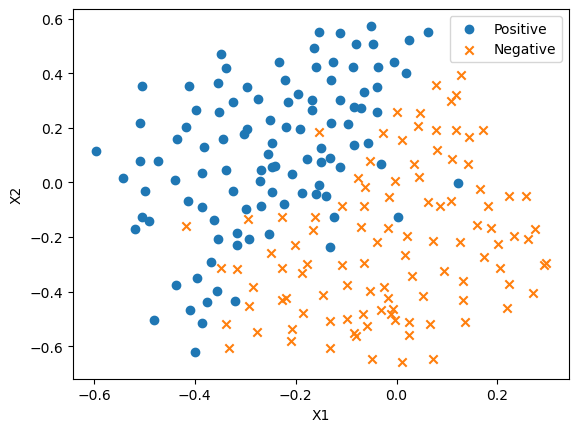

In [13]:
# Plot training data
plt.figure()
plt.scatter(X3[y3.flatten() == 1, 0], X3[y3.flatten() == 1, 1], marker='o', label='Positive')
plt.scatter(X3[y3.flatten() == 0, 0], X3[y3.flatten() == 0, 1], marker='x', label='Negative')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [14]:
# Load ex6data3
dfVal = pd.read_csv('ex5data3xVal.csv',header = None)
dfVal.head()

,0,1,2
0,-0.353062,-0.673902,0
1,-0.227126,0.447320,1
2,0.092898,-0.753524,0
3,0.148243,-0.718473,0
4,-0.001512,0.162928,0


In [15]:
m,n = dfVal.shape
XVal= np.array(dfVal.loc[:,0:n-2].values)
yVal = np.array(dfVal.loc[:,n-1].values,ndmin=2).reshape(-1).T

yVal_copy = yVal.copy()

In [16]:
C, sigma, accuracy = dataset3Params(X3, y3, XVal,yVal)
print('Training accuracy = {:.2f}'.format(accuracy*100))
print('C = {C:.2f}')


Training ...
.......................................................... Done! 



Training ...
............................................ Done! 



Training ...
......................................... Done! 



Training ...
...................... Done! 



Training ...
........................................ Done! 



Training ...
................ Done! ....



Training ...
.................................... Done! 



Training ...
............................ Done! 



Training ...
................................................ Done! 



Training ...
.....................................................
.... Done! 



Training ...
........................... Done! 



Training ...
.................................................
.......... Done! 



Training ...
.............................. Done! 



Training ...
..................... Done! 



Training ...
................. Done! 



Training ...
.............. Done! ......



Training ...
................................

In [17]:
C,sigma

(0.3, 0.1)

In [18]:
model = svmTrain(X3, y3, C, lambda x1, x2: gaussianKernel(x1, x2, sigma))


Training ...
..........................................................
......................................................................
.......................................................... Done! 




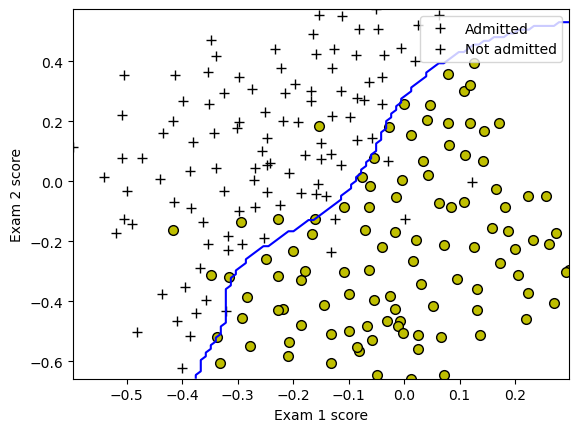

In [19]:
visualizeBoundary(X3, y3_copy, model)

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = svmPredict(model, X3).reshape(-1)
# Confusion Matrix
cm = confusion_matrix(y3_copy, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 99   6]
 [  5 101]]


In [21]:
# Accuracy Score
accuracy = accuracy_score(y3_copy, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.9478672985781991


In [27]:
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a sample dataset
X, y = make_classification(n_samples=100,  random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM with RBF kernel
svm = SVC(kernel='linear',degree=3, coef0=1, C=10.0,  gamma='scale')
svm.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9666666666666667


In [33]:
X.shape

(100, 20)

In [35]:
X[:10,:]

array([[-2.02514259,  0.0291022 , -0.47494531, -0.11473644,  0.50498728,
         0.08896214,  0.40498171, -0.65332923,  0.18645431, -0.66178646,
        -0.07133524,  2.14394409,  1.76545424,  0.85243333,  0.63391902,
         0.08714206, -0.79252074, -0.33450124,  0.86575519, -1.20029641],
       [ 1.61371127,  0.65992405, -0.15005559, -1.22760782,  0.59740007,
         0.86561977,  0.01557905,  0.12557645,  0.4535343 , -0.24415664,
        -1.15806823,  0.32135722, -0.17307182,  0.96408717,  0.42192075,
         0.96335953,  1.18947049,  1.37570681,  0.70117274, -0.2975635 ],
       [ 0.16645221,  0.95057302,  1.42050425, -0.53099696, -0.62314053,
        -2.25553963,  0.47141556, -0.57074629,  0.49245126,  0.28916864,
        -0.27062383, -1.12272202, -0.83235557,  2.45530014,  0.38240975,
        -1.69200458, -0.63773998,  1.18901653, -0.55547712, -0.63738713],
       [ 0.69822331, -0.32066954,  1.7359638 , -0.53523521,  1.31739407,
        -1.14658127, -0.48388583,  0.19791078,  

In [36]:
y[:10]

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 1])

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define pipeline: Scaling + SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Define parameter grid
param_grid = {
    'svm__kernel': ['linear', 'rbf', 'poly','sigmoid'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto'],           # Only relevant for rbf/poly
    'svm__degree': [2, 3, 4]                   # Only used for poly
}

# Grid search
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='recall', verbose=1)
grid_search.fit(X, y)

# Print best parameters
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best parameters: {'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 'scale', 'svm__kernel': 'poly'}
Best cross-validation score: 0.9700000000000001
